In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

In [2]:
df = pd.read_csv(r'C:\Users\chigi\OneDrive\mlprojectdataset.csv', header=1)
df = df.drop(columns=['id'])

print("Non-numeric columns:", df.select_dtypes(exclude=[np.number]).columns.tolist())
print("Total missing values:", df.isnull().sum().sum())

X = df.drop(columns=['class'])
y = df['class']

Non-numeric columns: []
Total missing values: 0


In [3]:
def cal_dist(train_data, test_point, metric='euclidean'):
    if metric == 'euclidean':
        return np.sqrt(np.sum((train_data - test_point) ** 2, axis=1))
    elif metric == 'manhattan':
        return np.sum(np.abs(train_data - test_point), axis=1)
    else:
        raise ValueError('Unknown metric: ' + metric)

In [4]:
def bubble_sort(distances):
    n = len(distances)
    dist = distances.copy()
    indices = np.arange(n)
    for i in range(n):
        for j in range(0, n - i - 1):
            if dist[j] > dist[j + 1]:
                dist[j], dist[j + 1] = dist[j + 1], dist[j]
                indices[j], indices[j + 1] = indices[j + 1], indices[j]
    return dist, indices


In [5]:
def insertion_sort(distances):
    n = len(distances)
    dist = distances.copy()
    indices = np.arange(n)
    for i in range(1, n):
        key_dist = dist[i]
        key_idx = indices[i]
        j = i - 1
        while j >= 0 and dist[j] > key_dist:
            dist[j + 1] = dist[j]
            indices[j + 1] = indices[j]
            j -= 1
        dist[j + 1] = key_dist
        indices[j + 1] = key_idx
    return dist, indices

In [6]:
def merge_sort(distances, indices=None):
    if indices is None:
        indices = np.arange(len(distances))
    if len(distances) <= 1:
        return distances, indices
    mid = len(distances) // 2
    left_d, left_i = merge_sort(distances[:mid], indices[:mid])
    right_d, right_i = merge_sort(distances[mid:], indices[mid:])
    merged_d, merged_i = [], []
    i = j = 0
    while i < len(left_d) and j < len(right_d):
        if left_d[i] <= right_d[j]:
            merged_d.append(left_d[i]); merged_i.append(left_i[i]); i += 1
        else:
            merged_d.append(right_d[j]); merged_i.append(right_i[j]); j += 1
    merged_d.extend(left_d[i:]); merged_i.extend(left_i[i:])
    merged_d.extend(right_d[j:]); merged_i.extend(right_i[j:])
    return np.array(merged_d), np.array(merged_i)

In [7]:
def sort_distances(distances, algorithm='merge'):
    if algorithm == 'bubble':
        return bubble_sort(distances)
    elif algorithm == 'insertion':
        return insertion_sort(distances)
    elif algorithm == 'merge':
        return merge_sort(distances)
    else:
        raise ValueError('Unknown algorithm: ' + algorithm)

In [8]:
def get_k_neighbors(sorted_dist, sorted_idx, k):
    kth_distance = sorted_dist[k - 1]
    tie_mask = sorted_dist == kth_distance
    tie_positions = np.where(tie_mask)[0]
    if len(tie_positions) > 1:
        print(f"Tie at distance {kth_distance}, indices {sorted_idx[tie_positions]}")
    return sorted_dist[:k], sorted_idx[:k]

In [9]:
def vote(neighbor_dist, neighbor_idx, y_train_arr, weighted=False):
    neighbor_labels = y_train_arr[neighbor_idx]
    classes = np.unique(neighbor_labels)
    if weighted:
        weights = 1 / (neighbor_dist + 1e-8)
        class_scores = {c: weights[neighbor_labels == c].sum() for c in classes}
    else:
        class_scores = {c: np.sum(neighbor_labels == c) for c in classes}
    max_score = max(class_scores.values())
    tied = [c for c, s in class_scores.items() if s == max_score]
    return min(tied) if len(tied) > 1 else tied[0]

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
y_train_arr = y_train.values
y_test_arr = y_test.values
print("X_train:", X_train.shape, "| X_test:", X_test.shape)

# confirm all 3 sorting algorithms agree
d0 = cal_dist(X_train, X_test[0], metric='euclidean')
for algo in ['bubble', 'insertion', 'merge']:
    sd, si = sort_distances(d0, algorithm=algo)
    print(algo, "top-5 idx:", si[:5])

X_train: (529, 753) | X_test: (227, 753)
bubble top-5 idx: [136 350  50 163 164]
insertion top-5 idx: [136 350  50 163 164]
merge top-5 idx: [136 350  50 163 164]


In [11]:
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(X_train, y_train)
print("sklearn KNN (k=3) accuracy:", neigh.score(X_test, y_test))
print(neigh.predict(X_test)[:10])

sklearn KNN (k=3) accuracy: 0.8678414096916299
[1 1 1 0 1 1 1 1 1 1]


In [12]:
class MyKNN:
    def __init__(self, n_neighbors=5, metric='euclidean', algorithm='merge', weighted=False):
        self.k = n_neighbors
        self.metric = metric
        self.algorithm = algorithm
        self.weighted = weighted

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)
        return self

    def _predict_one(self, test_point):
        distances = cal_dist(self.X_train, test_point, metric=self.metric)
        sorted_dist, sorted_idx = sort_distances(distances, algorithm=self.algorithm)
        neighbor_dist, neighbor_idx = get_k_neighbors(sorted_dist, sorted_idx, self.k)
        return vote(neighbor_dist, neighbor_idx, self.y_train, weighted=self.weighted)

    def predict(self, X_test):
        X_test = np.array(X_test)
        return np.array([self._predict_one(pt) for pt in X_test])

    def score(self, X_test, y_test):
        y_test = np.array(y_test)
        preds = self.predict(X_test)
        return np.mean(preds == y_test)

model = MyKNN(n_neighbors=5, metric='euclidean', weighted=False)
model.fit(X_train, y_train)
print("MyKNN (k=5, unweighted) accuracy:", model.score(X_test, y_test))
print(model.predict(X_test)[:10])

MyKNN (k=5, unweighted) accuracy: 0.8502202643171806
[1 1 1 1 1 1 1 0 1 1]


MyKNN accuracies: [0.9074889867841409, 0.8678414096916299, 0.8502202643171806, 0.8370044052863436, 0.8149779735682819, 0.8281938325991189, 0.8370044052863436, 0.8325991189427313]
sklearn accuracies: [0.9074889867841409, 0.8678414096916299, 0.8502202643171806, 0.8370044052863436, 0.8149779735682819, 0.8281938325991189, 0.8370044052863436, 0.8325991189427313]


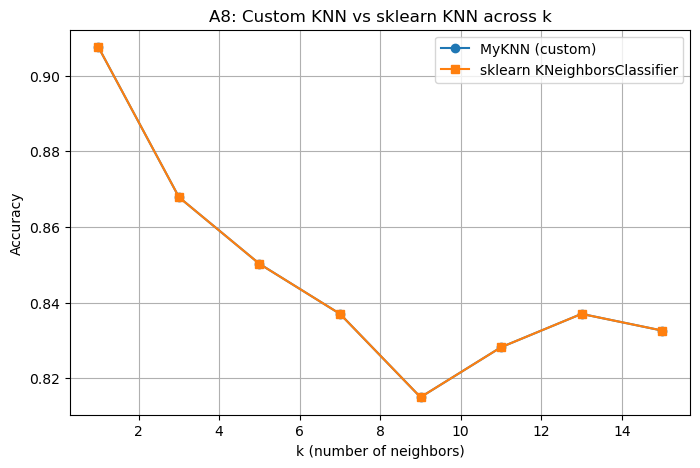

In [36]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
my_accuracies = []
sklearn_accuracies = []

for k in k_values:
    m = MyKNN(n_neighbors=k, weighted=False)
    m.fit(X_train, y_train)
    my_accuracies.append(m.score(X_test, y_test))

    sk = KNeighborsClassifier(n_neighbors=k)
    sk.fit(X_train, y_train)
    sklearn_accuracies.append(sk.score(X_test, y_test))

print("MyKNN accuracies:", my_accuracies)
print("sklearn accuracies:", sklearn_accuracies)

plt.figure(figsize=(8, 5))
plt.plot(k_values, my_accuracies, marker='o', label='MyKNN (custom)')
plt.plot(k_values, sklearn_accuracies, marker='s', label='sklearn KNeighborsClassifier')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('A8: Custom KNN vs sklearn KNN across k')
plt.legend()
plt.grid(True)
plt.show()

Weighted MyKNN accuracies: [0.9074889867841409, 0.8678414096916299, 0.8502202643171806, 0.8370044052863436, 0.8193832599118943, 0.8281938325991189, 0.8370044052863436, 0.8325991189427313]


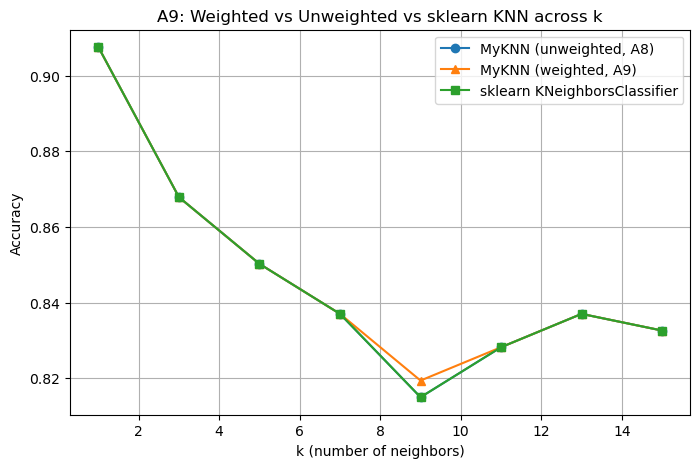

In [14]:
weighted_accuracies = []
for k in k_values:
    m = MyKNN(n_neighbors=k, weighted=True)
    m.fit(X_train, y_train)
    weighted_accuracies.append(m.score(X_test, y_test))

print("Weighted MyKNN accuracies:", weighted_accuracies)

plt.figure(figsize=(8, 5))
plt.plot(k_values, my_accuracies, marker='o', label='MyKNN (unweighted, A8)')
plt.plot(k_values, weighted_accuracies, marker='^', label='MyKNN (weighted, A9)')
plt.plot(k_values, sklearn_accuracies, marker='s', label='sklearn KNeighborsClassifier')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('A9: Weighted vs Unweighted vs sklearn KNN across k')
plt.legend()
plt.grid(True)
plt.show()